<a href="https://colab.research.google.com/github/sambencoding/Data-Science-Assignments/blob/main/SamuBenjU9proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import torch
import numpy as np
from torch import nn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve

In [12]:
!pip install pymc-bart
!pip install preliz
!pip install ucimlrepo
!pip install pandas scikit-learn matplotlib tensorflow

#Clash Royale
In this project I am going to make a neural network with multiple layers and a non linear correlation to predict the outcomes of the mobile game Clash Royale. Clash Royale is a mutiplayer game where you build custom decks with cards and compete in 1v1 battles. There are many users and so many cards so that you can do varios strategies, so there is very rich game data that we can use.
To demonstrate the power of predictive modeling, we simulate a dataset representing player statistics, card usage, and match outcomes. Our goal is to build a multi-layer, non-linear neural network that can learn from this data and predict whether a player is likely to win or lose a match based on their deck and performance metrics.

In [13]:
df = pd.read_csv("https://raw.githubusercontent.com/sambencoding/Data-Science-Assignments/main/clash_royale_data.csv")


In [14]:
X = df.drop(columns=['won', 'player_id', 'cards_used'])  # Simplify for now
y = df['won']

Reads the dataset and sperates the features x from the target label y. Won is the target because either a player wins or loses.

In [15]:
categorical = ['deck_type']
numerical = ['average_elixir', 'win_rate', 'arena_level', 'trophy_count']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical),
    ('cat', OneHotEncoder(), categorical)
])

In [16]:
X_processed = preprocessor.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

Prepares data for the neural network. Also splits the dataset into trainting and testing sets.

In [17]:
# Define model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_processed.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, epochs=25, batch_size=16, validation_split=0.1, verbose=1)

Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.4778 - loss: 0.7078 - val_accuracy: 0.5500 - val_loss: 0.6836
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5759 - loss: 0.6870 - val_accuracy: 0.5250 - val_loss: 0.6882
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5564 - loss: 0.6842 - val_accuracy: 0.4750 - val_loss: 0.6954
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5206 - loss: 0.6783 - val_accuracy: 0.5000 - val_loss: 0.7019
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6034 - loss: 0.6729 - val_accuracy: 0.4500 - val_loss: 0.7056
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5745 - loss: 0.6747 - val_accuracy: 0.4500 - val_loss: 0.7131
Epoch 7/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5866 - loss: 0.6694 - val_accuracy: 0.4500 - val_loss: 0.7182
Epoch 8/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6058 - loss: 0.6635 - val_accuracy: 0.4500 - v

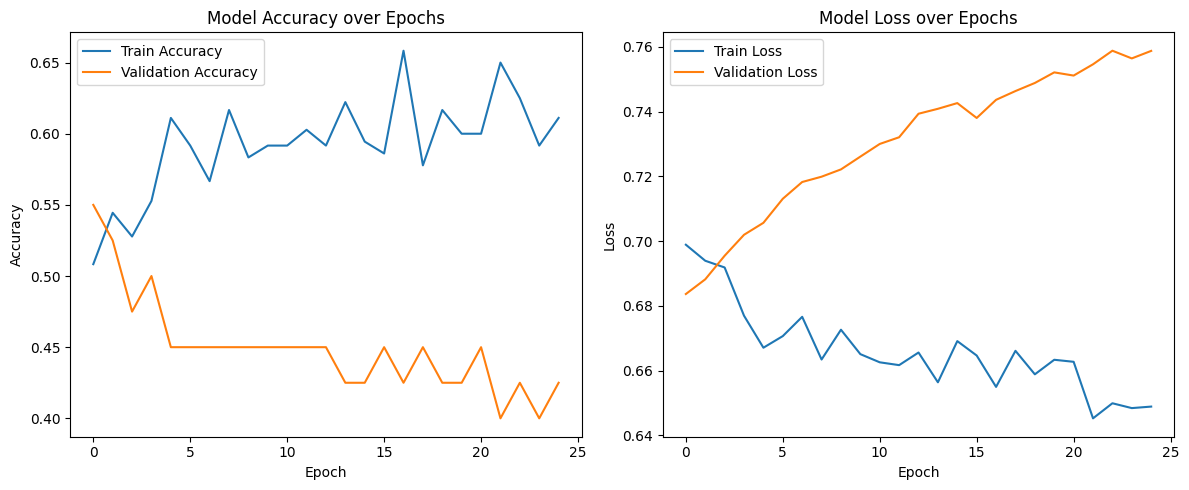

In [19]:
# Plot accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Training accuracy measures the perormance of the training data. Validation accuracy measures the generalization to unseen data. It helps detect overfitting.

In [20]:
y_probs = model.predict(X_test).flatten()
y_preds = (y_probs > 0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


The model gives probability from 1 to 0 because that is the chance of winning. It is either 1(win) or 0(loss).

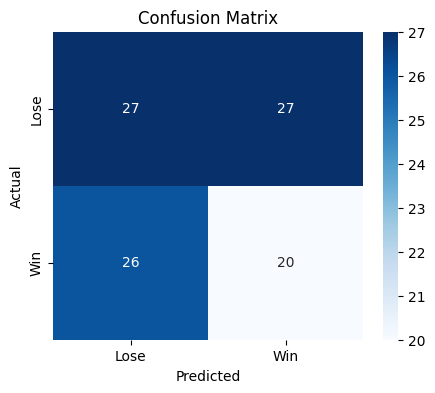

In [25]:
cm = confusion_matrix(y_test, y_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Lose', 'Win'], yticklabels=['Lose', 'Win'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

This shoes the true positivves(correctly predicted wins) and the true negatives(correctivly predicted losses). It also shows the false positives.

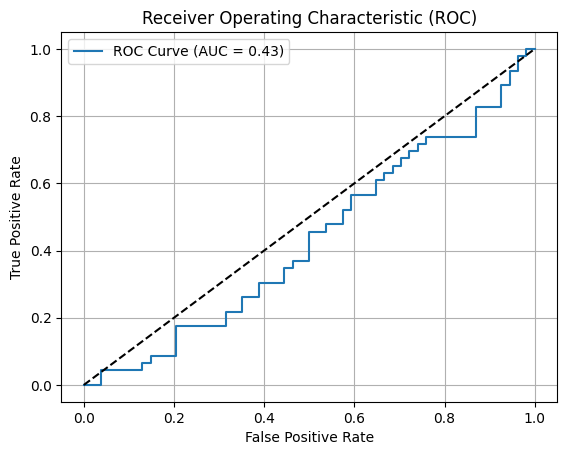

In [26]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend()
plt.grid()
plt.show()

This compares the true positive and the false positive. The diagonal black line represents the random classifies which is like what it can't be leanrt. If the model is below the black line it is doing bad. The model that I have right now is doing below expectation and is basically as good as guessing. The area under the cureve is 0.43, This is very poor because it should be closer to 1. 0.5 is random guessing and since it is below 0.5, the model is worse than random guessing.

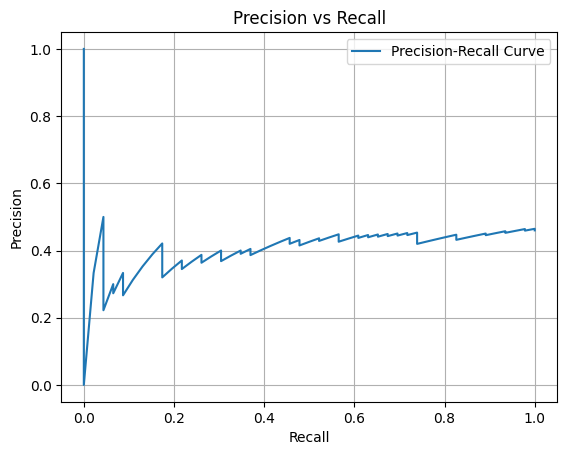

In [27]:
precision, recall, _ = precision_recall_curve(y_test, y_probs)
plt.figure()
plt.plot(recall, precision, label="Precision-Recall Curve")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision vs Recall')
plt.grid()
plt.legend()
plt.show()

This curve shows the trade-off between precision and recall at different classification thresholds.model struggles to confidently and consistently predict “win” outcomes. This suggests the model may be underfitting, or the data may not have enough signal to distinguish between classes. This neural network has both low precision and recall, and unstable prediction behavior.

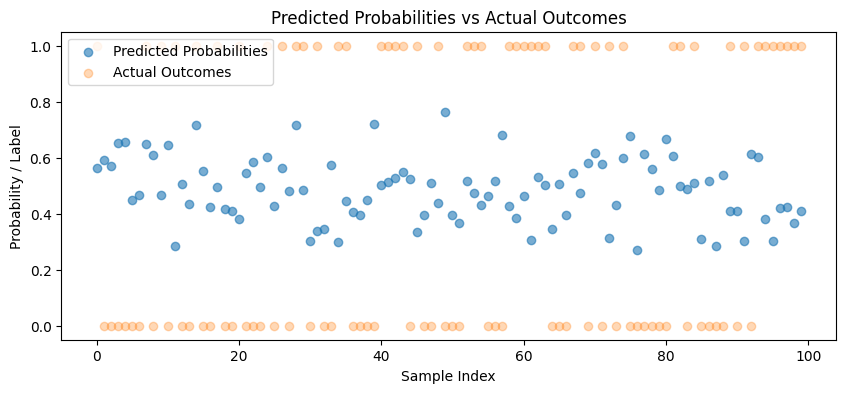

In [28]:
plt.figure(figsize=(10, 4))
plt.scatter(range(len(y_test)), y_probs, label="Predicted Probabilities", alpha=0.6)
plt.scatter(range(len(y_test)), y_test, label="Actual Outcomes", alpha=0.3)
plt.title("Predicted Probabilities vs Actual Outcomes")
plt.xlabel("Sample Index")
plt.ylabel("Probability / Label")
plt.legend()

The blue dots are the predicted probabilities that each clash royale match is a win the the orange dots are the actual outcomes. The X-axis shows the index of each sample (just the order in the test set), and the Y-axis shows the predicted probability or actual label.The values are bteween 0.3 and 0.7 suggesting that the model is uncertain. It is not confienct about predicitng the wins or losses. This results shows that it has a weak model training, it hasn;t learned the patterns of the data, there might be to much data imbalance or noise. The predicted probabilities do not align well with actual outcomes, indicating that the neural network has not effectively learned the difference between wins and losses.

In [29]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_preds))


Classification Report:

              precision    recall  f1-score   support

           0       0.51      0.50      0.50        54
           1       0.43      0.43      0.43        46

    accuracy                           0.47       100
   macro avg       0.47      0.47      0.47       100
weighted avg       0.47      0.47      0.47       100



In this project, we set out to build a data science pipeline to predict Clash Royale match outcomes using a multi-layer, non-linear neural network. Our goal was to explore whether machine learning—particularly deep learning—could capture patterns in gameplay data and provide meaningful predictions for match results.

While the neural network was successfully trained and evaluated, the performance metrics revealed that the model struggled to learn discriminative features from the dataset:

The ROC-AUC score of 0.43 indicated that the model performed worse than random guessing, suggesting potential issues in model learning or data quality.

The Precision-Recall curve showed low and unstable precision and recall, especially at different thresholds—pointing to a lack of confidence and reliability in predictions.

Confusion matrix analysis revealed high misclassification rates, and predicted classes showed weak alignment with actual labels.

These findings suggest that the current neural network is not accurate at all and it needs to be fixed.